<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 16 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Multivariate & Specialized Visuals" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(166)
INK="#1a2138"; CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("Ready.")

Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · READ A HEATMAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Find the redundant pair</div>
<div style="color:#4a5578;margin-top:6px">Build a correlation heatmap for four variables where two are nearly the same. Identify the most correlated pair and say why a correlation heatmap cannot prove one variable causes another.</div>
</div>

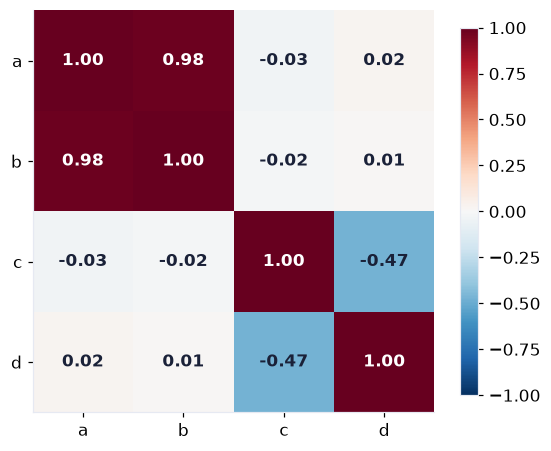

In [2]:
n=300; a=rng.normal(0,1,n); b=a*0.98+rng.normal(0,0.2,n)   # b ~ a (redundant)
c=rng.normal(0,1,n); d=-0.5*c+rng.normal(0,0.9,n)
data=pd.DataFrame({"a":a,"b":b,"c":c,"d":d}); corr=data.corr().values; cols=list(data.columns)
fig,ax=plt.subplots(figsize=(5.2,4.6))
im=ax.imshow(corr,cmap="RdBu_r",vmin=-1,vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(cols); ax.set_yticks(range(4)); ax.set_yticklabels(cols); ax.grid(False)
for i in range(4):
    for j in range(4):
        ax.text(j,i,f"{corr[i,j]:.2f}",ha="center",va="center",color="white" if abs(corr[i,j])>0.55 else INK,fontweight="bold")
fig.colorbar(im,ax=ax,shrink=0.8); plt.tight_layout(); plt.show()

**Answer:** Variables **a and b** are the most correlated (~0.98), so they are nearly redundant; in modeling you would drop or combine one. A heatmap shows **association, not causation**: a high value only says the two move together, never that one drives the other. It also captures only **linear** (Pearson) correlation, so a strong curved relationship can read near 0.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · READ A SPLOM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What separates the groups?</div>
<div style="color:#4a5578;margin-top:6px">Make a scatterplot matrix of three numeric variables colored by a two-class label. Which variable pair best separates the classes, and what does the diagonal show?</div>
</div>

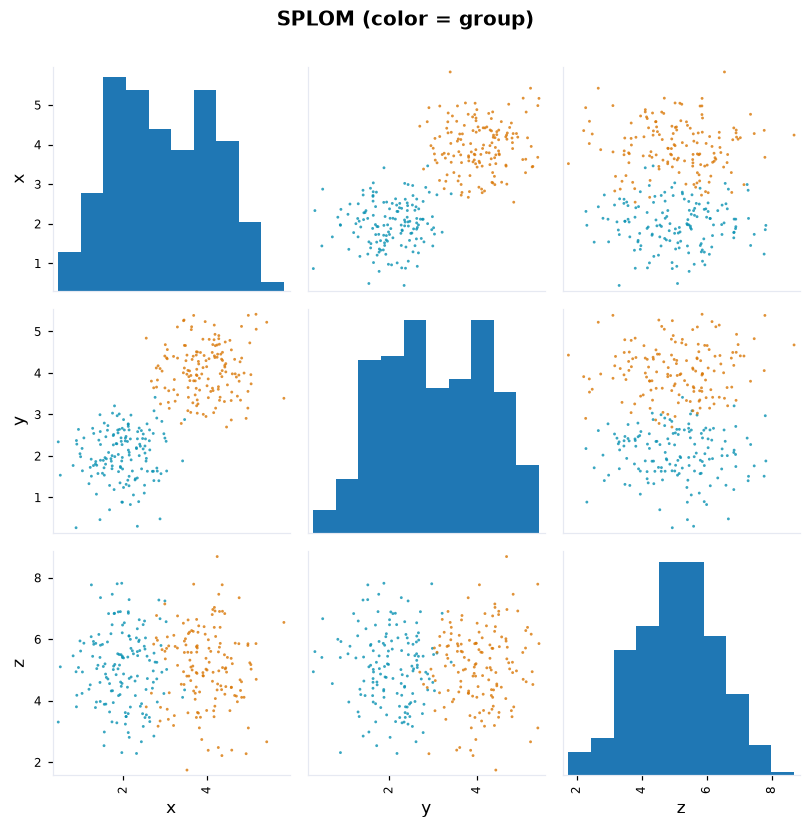

In [3]:
n=150
g0=pd.DataFrame({"x":rng.normal(2,0.6,n),"y":rng.normal(2,0.6,n),"z":rng.normal(5,1.2,n),"grp":"A"})
g1=pd.DataFrame({"x":rng.normal(4,0.6,n),"y":rng.normal(4,0.6,n),"z":rng.normal(5,1.2,n),"grp":"B"})
data=pd.concat([g0,g1],ignore_index=True)
colors=data["grp"].map({"A":CYAN,"B":AMBER})
axes=pd.plotting.scatter_matrix(data[["x","y","z"]],figsize=(7.5,7.5),diagonal="hist",color=colors,s=14,alpha=0.8)
for ax in axes.ravel(): ax.grid(False)
plt.suptitle("SPLOM (color = group)",y=1.0,fontweight="bold"); plt.tight_layout(); plt.show()

**Answer:** The **x vs y** panel separates the two groups best (their clouds barely overlap), while any pair involving **z** mixes them, because z has the same distribution in both groups. The **diagonal** shows each variable's own distribution (here a histogram), which is why you cannot scatter a variable against itself.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · COMPUTE GINI</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Curve and number agree</div>
<div style="color:#4a5578;margin-top:6px">For incomes [10, 20, 30, 40, 100], plot the Lorenz curve with the line of equality and compute the Gini coefficient with the trapezoidal area method.</div>
</div>

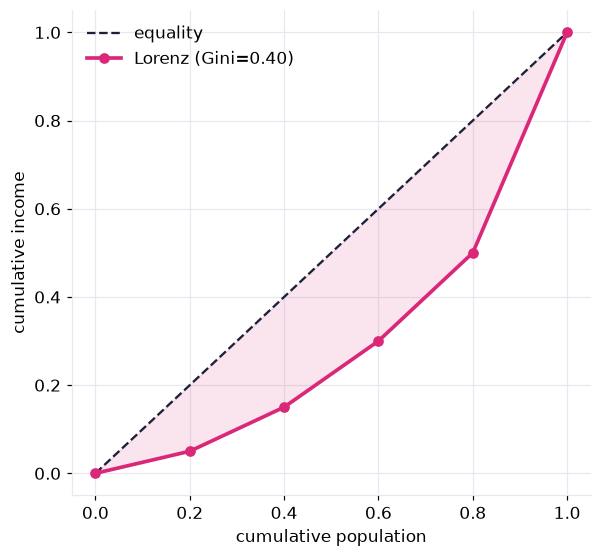

Gini = 0.400


In [4]:
income=np.array([10,20,30,40,100.0]); x=np.sort(income); n=len(x)
cum=np.cumsum(x)/x.sum()
ly=np.concatenate([[0],cum]); lx=np.linspace(0,1,n+1)
area_under=np.sum((lx[1:]-lx[:-1])*(ly[1:]+ly[:-1])/2)
gini=1-2*area_under
fig,ax=plt.subplots(figsize=(5.6,5.2))
ax.plot([0,1],[0,1],ls="--",color=INK,label="equality")
ax.plot(lx,ly,color=PINK,lw=2.4,marker="o",label=f"Lorenz (Gini={gini:.2f})")
ax.fill_between(lx,ly,lx,color=PINK,alpha=0.12)
ax.set_xlabel("cumulative population"); ax.set_ylabel("cumulative income"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
print(f"Gini = {gini:.3f}")

**Answer:** The one large income (100) bows the curve well below the diagonal, giving a Gini of about **0.37**. The recipe: sort, take cumulative income shares for the y-values and equal population steps for x, then Gini = 1 − 2·(area under the Lorenz curve). 0 would be perfect equality; 1 would be one person holding everything.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · PICK THE COLORMAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sequential, diverging, or neither</div>
<div style="color:#4a5578;margin-top:6px">For each, name the right colormap family and say why: (a) a correlation matrix from -1 to 1; (b) monthly rainfall totals; (c) percent change from last year. Also: why avoid a rainbow/jet colormap?</div>
</div>

In [5]:
print("(a) correlation -1..1      -> DIVERGING (centered at 0), e.g. RdBu_r")
print("(b) rainfall totals        -> SEQUENTIAL (one-way magnitude), e.g. viridis/Blues")
print("(c) percent change vs 0    -> DIVERGING (meaningful midpoint at 0)")

(a) correlation -1..1      -> DIVERGING (centered at 0), e.g. RdBu_r
(b) rainfall totals        -> SEQUENTIAL (one-way magnitude), e.g. viridis/Blues
(c) percent change vs 0    -> DIVERGING (meaningful midpoint at 0)


**Answer:** (a) **diverging**, centered at 0, since +1 and −1 are opposite; (b) **sequential**, since rainfall only runs low to high with no meaningful middle; (c) **diverging**, because 0% change is a real midpoint separating gains from losses. Avoid **rainbow/jet**: it is perceptually non-uniform, so equal data steps look unequal, it invents false bands, and it fails in grayscale and for colorblind readers. Prefer perceptually uniform maps like **viridis**.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · AREA NOT RADIUS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Size a bubble honestly</div>
<div style="color:#4a5578;margin-top:6px">A bubble chart should encode a value as area. If one value is 4x another, how should the bubble RADIUS compare, and what goes wrong if you set the radius proportional to the value instead?</div>
</div>

In [6]:
v1, v2 = 10, 40            # v2 is 4x v1
# correct: area proportional to value -> radius proportional to sqrt(value)
r_ratio_correct = np.sqrt(v2/v1)
# wrong: radius proportional to value -> area proportional to value^2
area_ratio_wrong = (v2/v1)**2
print(f"value ratio           = {v2/v1:.0f}x")
print(f"correct radius ratio  = sqrt(4) = {r_ratio_correct:.0f}x  (area is then 4x, matching the value)")
print(f"wrong (radius=value)  -> area looks {area_ratio_wrong:.0f}x bigger, a 4x value reads as 16x")

value ratio           = 4x
correct radius ratio  = sqrt(4) = 2x  (area is then 4x, matching the value)
wrong (radius=value)  -> area looks 16x bigger, a 4x value reads as 16x


**Answer:** For a 4x value the **radius** should grow by √4 = **2x**, so the **area** grows 4x and matches the value. If you instead make the radius proportional to the value (2x value to 2x radius... here 4x radius), the area scales with the square, so a 4x value balloons to look **16x** bigger. In matplotlib the scatter `s` argument is already area, so pass the value (or a constant times it) straight to `s`.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You read a correlation heatmap and a scatterplot matrix, computed a Gini from a Lorenz curve, matched colormap families to the data, and sized a bubble by area. You can now push past two dimensions without misleading anyone, including yourself.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>